#Spider ML Base Task

##Importing necessary libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

device = torch.device("cuda") #Device set to GPU

##Loading dataset and splitting into Train/Validation/Test



In [ ]:
full_dataset = datasets.FashionMNIST(
    root="./data", #In data file
    train=True,
    download=True, #Makes it faster
    transform=transforms.ToTensor())

train_size = int(0.8 * len(full_dataset)) #80% of Train is for training while 20% is for validation dataset
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset,[train_size, val_size],) #Randomise

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transforms.ToTensor())

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 201kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.82MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 27.3MB/s]


##Create Sequence of layers
1. First flatten the image to form vector
2. From 28*28 activations compress to 256 activations and apply Relu
3. From previous 256 activations compress to 128 activations and apply ReLU
4. Finally output layer to have 10 activations for 10 possible classes

Included Dropouts because overfitting was detected

In [ ]:
classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 256),
    nn.ReLU(), #Layer 1

    nn.Dropout(0.3),

    nn.Linear(256, 128),
    nn.ReLU(), #Layer 2

    nn.Dropout(0.3),

    nn.Linear(128, 10)).to(device)

##Setting Loss criteria and Optimizer
Using CrossEntropyLoss() since it is a classification problem and Adam optimiser with a small Learning rate and a weight decay to regularise the parameters

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    classifier.parameters(),
    lr=0.001,
    weight_decay=1e-4)

In [ ]:
epochs = 20
train_losses = []
val_losses = []
train_accs = []
val_accs = [] #Gathering data to plot

for epoch in range(epochs):
    classifier.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad() #Clear the prev gradients
        outputs = classifier(images) #Forward Prop
        loss = criterion(outputs, labels) #Loss Function
        loss.backward() #Backprop
        optimizer.step() #Optimize parameters

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1) #Only care about the labels (indices)
        total += labels.size(0)
        correct += (predicted == labels).sum().item() #No of predictions that match labels correctly

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    classifier.eval() #evaluation mode

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad(): #no need for gradients anymore
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = classifier(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = running_loss / len(val_loader)
    val_acc = 100 * correct / total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch+1}/{epochs} / "
        f"Train Loss: {train_loss} / "
        f"Train Acc: {train_acc}% / "
        f"Val Loss: {val_loss} / "
        f"Val Acc: {val_acc}%"
    )

Epoch 1/20 / Train Loss: 0.2736418468952179 / Train Acc: 89.89375% / Val Loss: 0.32007310904086905 / Val Acc: 88.55833333333334%
Epoch 2/20 / Train Loss: 0.26970189944903056 / Train Acc: 89.84583333333333% / Val Loss: 0.3004618229225595 / Val Acc: 89.10833333333333%
Epoch 3/20 / Train Loss: 0.2652371379335721 / Train Acc: 89.94375% / Val Loss: 0.30773722364547407 / Val Acc: 88.54166666666667%
Epoch 4/20 / Train Loss: 0.2671367003917694 / Train Acc: 89.90416666666667% / Val Loss: 0.3119299591697277 / Val Acc: 88.775%
Epoch 5/20 / Train Loss: 0.26563910551865894 / Train Acc: 90.07291666666667% / Val Loss: 0.30548873813228405 / Val Acc: 88.99166666666666%
Epoch 6/20 / Train Loss: 0.26134261951843896 / Train Acc: 90.31666666666666% / Val Loss: 0.3216770348396707 / Val Acc: 88.325%
Epoch 7/20 / Train Loss: 0.264289617617925 / Train Acc: 90.05416666666666% / Val Loss: 0.30524774656650866 / Val Acc: 89.125%
Epoch 8/20 / Train Loss: 0.25893196686108905 / Train Acc: 90.13541666666667% / Val Los

##Plotting Figures for Accuracy and Loss vs Epoch

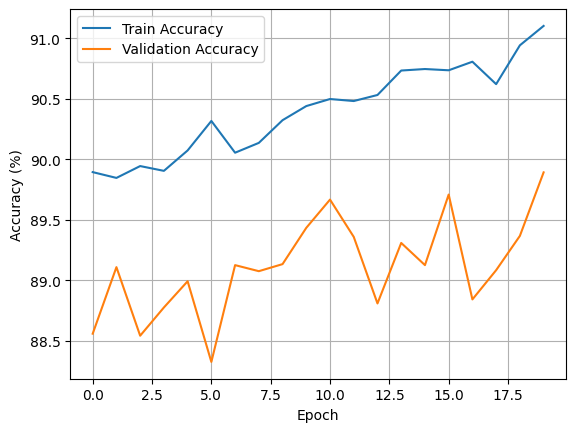

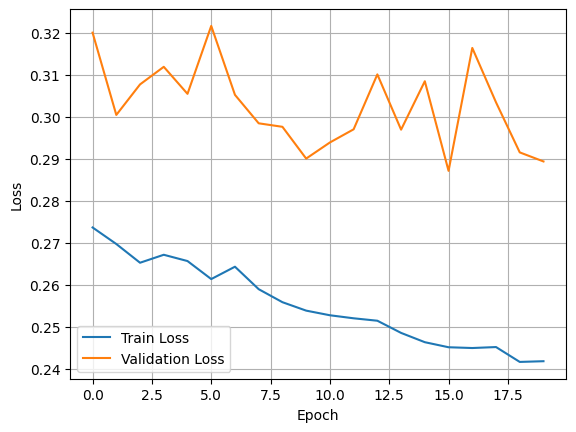

In [ ]:
plt.figure()
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.show()

plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

##Creating a Pickle file with all final parameters

In [ ]:
with open("savedparameters.pkl", "wb") as f:
    pickle.dump(classifier.state_dict(), f)

##Predicting Lables for Test set and finding Test Accuracy

In [ ]:
classifier.eval()
predictions = []
actual = []
with torch.no_grad():
    for images, target in test_loader:
        images = images.to(device)
        outputs = classifier(images)
        preds = torch.argmax(outputs,dim=1) #Find Index of final output (Index = Label)
        predictions.extend(preds.cpu().numpy())
        actual.extend(target)

submission = pd.DataFrame({"Predicted_Label": predictions, "Actual_Label": actual})
submission.to_csv("submission.csv",index=False)

print("Test Accuracy = ", ((np.array(predictions) - np.array(actual)) == 0).sum()/len(predictions)*100, "%")

Test Accuracy =  89.09 %
